In [16]:
# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# set column names (not included in magig04.data)
columns = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
    "class"
]

df = pd.read_csv(
    "magic04.data",
    header=None,
    names=columns
)

df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [18]:
def overview(df):
    '''
    Erstelle einen Überblick über einige wichtige Eigenschaften der Spalten eines DataFrames.
    VARs
        df: Der zu betrachtende DataFrame
    RETURNS:
        None
    '''
    df = df.copy()
    display(pd.DataFrame({'dtype': df.dtypes,                                   # Dtypes
                          'total': df.count(),                                  # Anzahl valider Einträge
                          'missing_n': df.isna().sum(),                         # Anzahl nan-Einträge
                          'missing_%': df.isna().mean()*100,                    # Anteil fehlender Daten in %
                          'uniques_n': df.nunique(),                            # Kardinalität (Anzahl einzigartiger Werte)
                          'uniques': [df[col].unique() for col in df.columns]   # Auflistung einzigartiger Werte
                         }))
overview(df)

,dtype,total,missing_n,missing_%,uniques_n,uniques
fLength,float64,19020,0,0.0,18643,"[28.7967, 31.6036, 162.052, 23.8172, 75.1362, ..."
fWidth,float64,19020,0,0.0,18200,"[16.0021, 11.7235, 136.031, 9.5728, 30.9205, 2..."
fSize,float64,19020,0,0.0,7228,"[2.6449, 2.5185, 4.0612, 2.3385, 3.1611, 2.908..."
fConc,float64,19020,0,0.0,6410,"[0.3918, 0.5303, 0.0374, 0.6147, 0.3168, 0.242..."
fConc1,float64,19020,0,0.0,4421,"[0.1982, 0.3773, 0.0187, 0.3922, 0.1832, 0.134..."
fAsym,float64,19020,0,0.0,18704,"[27.7004, 26.2722, 116.741, 27.2107, -5.5277, ..."
fM3Long,float64,19020,0,0.0,18693,"[22.011, 23.8238, -64.858, -6.4633, 28.5525, 4..."
fM3Trans,float64,19020,0,0.0,18390,"[-8.2027, -9.9574, -45.216, -7.1513, 21.8393, ..."
fAlpha,float64,19020,0,0.0,17981,"[40.092, 6.3609, 76.96, 10.449, 4.648, 3.613, ..."
fDist,float64,19020,0,0.0,18437,"[81.8828, 205.261, 256.788, 116.737, 356.462, ..."


* keine fehlenden Werte
* nur numerische Spalten, die auch numerisch sein sollen

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fLength,19020.0,53.250154,42.364855,4.2835,24.336000,37.14770,70.122175,334.1770
fWidth,19020.0,22.180966,18.346056,0.0000,11.863800,17.13990,24.739475,256.3820
fSize,19020.0,2.825017,0.472599,1.9413,2.477100,2.73960,3.101600,5.3233
fConc,19020.0,0.380327,0.182813,0.0131,0.235800,0.35415,0.503700,0.8930
fConc1,19020.0,0.214657,0.110511,0.0003,0.128475,0.19650,0.285225,0.6752
fAsym,19020.0,-4.331745,59.206062,-457.9161,-20.586550,4.01305,24.063700,575.2407
fM3Long,19020.0,10.545545,51.000118,-331.7800,-12.842775,15.31410,35.837800,238.3210
fM3Trans,19020.0,0.249726,20.827439,-205.8947,-10.849375,0.66620,10.946425,179.8510
fAlpha,19020.0,27.645707,26.103621,0.0000,5.547925,17.67950,45.883550,90.0000
fDist,19020.0,193.818026,74.731787,1.2826,142.492250,191.85145,240.563825,495.5610


In [ ]:
# check for dublicates including target
print(df.duplicated().sum())

115


In [31]:
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(
    by=list(df.columns)
)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class,abs_fAsym,abs_fM3Long,abs_fM3Trans,width_length_ratio,ellipse_area,brightest_pixel_share,alpha_alignment
15221,12.9176,11.3596,2.1123,0.7413,0.3900,15.0388,-5.6768,-11.5638,64.9330,227.1070,h,15.0388,5.6768,11.5638,0.879389,460.993439,0.526103,0.423678
18512,12.9176,11.3596,2.1123,0.7413,0.3900,15.0388,-5.6768,-11.5638,64.9330,227.1070,h,15.0388,5.6768,11.5638,0.879389,460.993439,0.526103,0.423678
14954,12.9801,10.8815,2.4175,0.7457,0.4723,-13.6970,6.0371,-7.0019,30.8030,78.2618,h,13.6970,6.0371,7.0019,0.838322,443.727840,0.633365,0.858933
18223,12.9801,10.8815,2.4175,0.7457,0.4723,-13.6970,6.0371,-7.0019,30.8030,78.2618,h,13.6970,6.0371,7.0019,0.838322,443.727840,0.633365,0.858933
13389,13.0287,10.9544,2.2000,0.7571,0.4511,-14.0985,5.7807,-10.1748,64.8700,182.9800,h,14.0985,5.7807,10.1748,0.840790,448.373103,0.595826,0.424674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12827,202.8290,73.9967,4.3622,0.0678,0.0364,-66.4079,-159.3540,-21.2584,76.1130,348.9780,h,66.4079,159.3540,21.2584,0.364823,47151.148349,0.536873,0.240008
14522,227.1840,22.5405,2.9325,0.4474,0.3102,-264.0340,135.8690,9.4616,48.2190,265.2380,h,264.0340,135.8690,9.4616,0.099217,16087.596315,0.693339,0.666285
18691,227.1840,22.5405,2.9325,0.4474,0.3102,-264.0340,135.8690,9.4616,48.2190,265.2380,h,264.0340,135.8690,9.4616,0.099217,16087.596315,0.693339,0.666285
12761,236.7150,92.6160,3.5200,0.1015,0.0539,-321.2090,122.7120,-89.4731,25.7824,71.2890,h,321.2090,122.7120,89.4731,0.391255,68875.009516,0.531034,0.900452


In [ ]:
# check for dublicates in features without target
feature_cols = df.columns.drop("class")

df.duplicated(
    subset=feature_cols,
    keep=False
).sum()

np.int64(230)

In [ ]:
feature_duplicates = df[
    df.duplicated(subset=feature_cols, keep=False)
]

feature_duplicates.sort_values(
    by=list(feature_cols)
)

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class,abs_fAsym,abs_fM3Long,abs_fM3Trans,width_length_ratio,ellipse_area,brightest_pixel_share,alpha_alignment
15221,12.9176,11.3596,2.1123,0.7413,0.3900,15.0388,-5.6768,-11.5638,64.9330,227.1070,h,15.0388,5.6768,11.5638,0.879389,460.993439,0.526103,0.423678
18512,12.9176,11.3596,2.1123,0.7413,0.3900,15.0388,-5.6768,-11.5638,64.9330,227.1070,h,15.0388,5.6768,11.5638,0.879389,460.993439,0.526103,0.423678
14954,12.9801,10.8815,2.4175,0.7457,0.4723,-13.6970,6.0371,-7.0019,30.8030,78.2618,h,13.6970,6.0371,7.0019,0.838322,443.727840,0.633365,0.858933
18223,12.9801,10.8815,2.4175,0.7457,0.4723,-13.6970,6.0371,-7.0019,30.8030,78.2618,h,13.6970,6.0371,7.0019,0.838322,443.727840,0.633365,0.858933
13389,13.0287,10.9544,2.2000,0.7571,0.4511,-14.0985,5.7807,-10.1748,64.8700,182.9800,h,14.0985,5.7807,10.1748,0.840790,448.373103,0.595826,0.424674
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12827,202.8290,73.9967,4.3622,0.0678,0.0364,-66.4079,-159.3540,-21.2584,76.1130,348.9780,h,66.4079,159.3540,21.2584,0.364823,47151.148349,0.536873,0.240008
14522,227.1840,22.5405,2.9325,0.4474,0.3102,-264.0340,135.8690,9.4616,48.2190,265.2380,h,264.0340,135.8690,9.4616,0.099217,16087.596315,0.693339,0.666285
18691,227.1840,22.5405,2.9325,0.4474,0.3102,-264.0340,135.8690,9.4616,48.2190,265.2380,h,264.0340,135.8690,9.4616,0.099217,16087.596315,0.693339,0.666285
12761,236.7150,92.6160,3.5200,0.1015,0.0539,-321.2090,122.7120,-89.4731,25.7824,71.2890,h,321.2090,122.7120,89.4731,0.391255,68875.009516,0.531034,0.900452


In [ ]:
# check for dublicates in features with different target
conflicts = (
    df.groupby(list(feature_cols))["class"]
      .nunique()
)

conflicts = conflicts[conflicts > 1]

print(len(conflicts))

0


* keine Dublikate bei denen bei gleichen Featurewerten ein anderes Ergebnis bei Klassifizierung herausgekommen ist
* Dublikate können entfernt werden, damit kein Data Leakage (gleicher Datensatz in df_train und df_test)

In [35]:
df = df.drop_duplicates().reset_index(drop=True)

<Axes: >

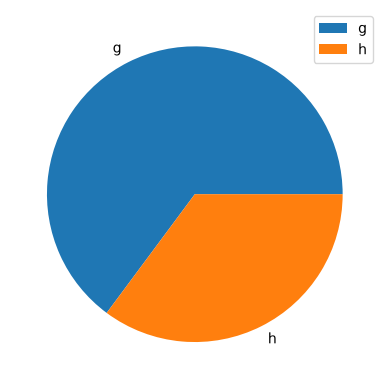

In [20]:
# check for class weights
crosstab = pd.crosstab(index=df['class'], columns='ratio', normalize=True)
crosstab.plot(kind='pie', y='ratio')

In [21]:
verteilung = pd.DataFrame({
    "Anzahl": df["class"].value_counts(),
    "Prozent": df["class"].value_counts(normalize=True).mul(100).round(2)
})

print(verteilung)

       Anzahl  Prozent
class                 
g       12332    64.84
h        6688    35.16


Zielklassen leicht unausgeglichen, später berücksichtigen

In [22]:
# generate features and target out of df
features = df.iloc[:, :-1]
target = df.iloc[:, -1]

<Axes: >

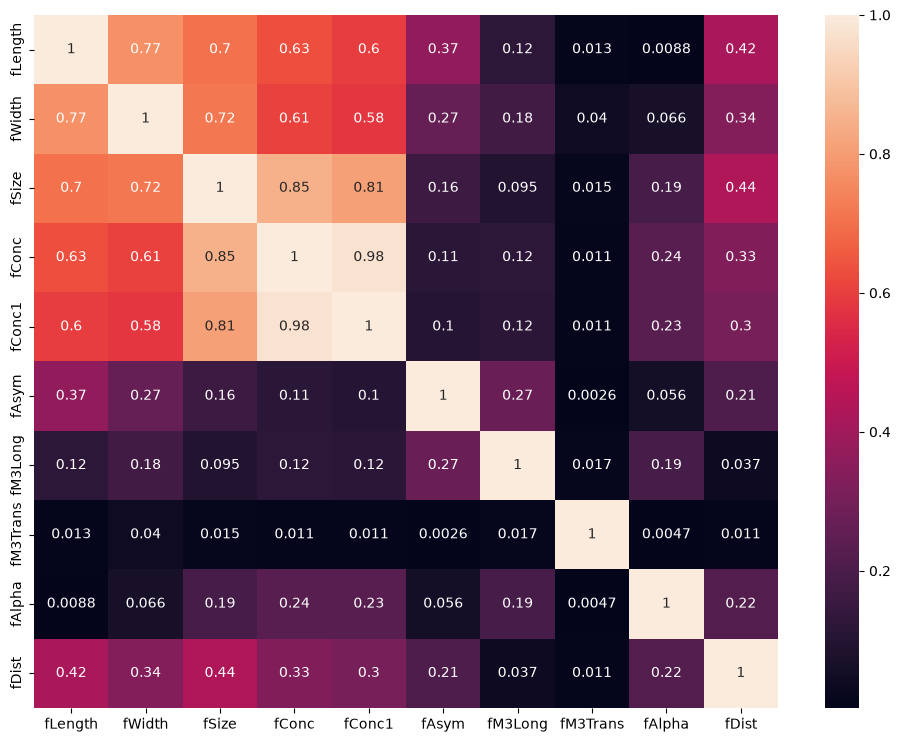

In [23]:
# plot heatmap of correlations
plt.figure(figsize=(12,9))
corr = features.corr()
sns.heatmap(corr.abs(),
            annot=True) # Heat map of absolute values of correlation matrix

* sehr starke Korrelation zwischen fConc und fConc1 und von den beiden Größen zu fSize
* starke Korrelation zwischen fSize und fWidth und fLength, verständlich, da diese beiden zur Gesamtgröße dazugehören


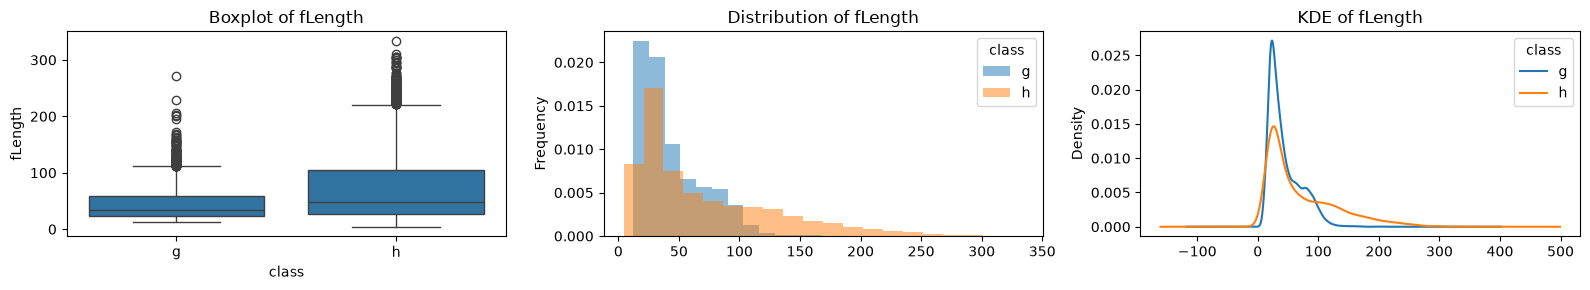

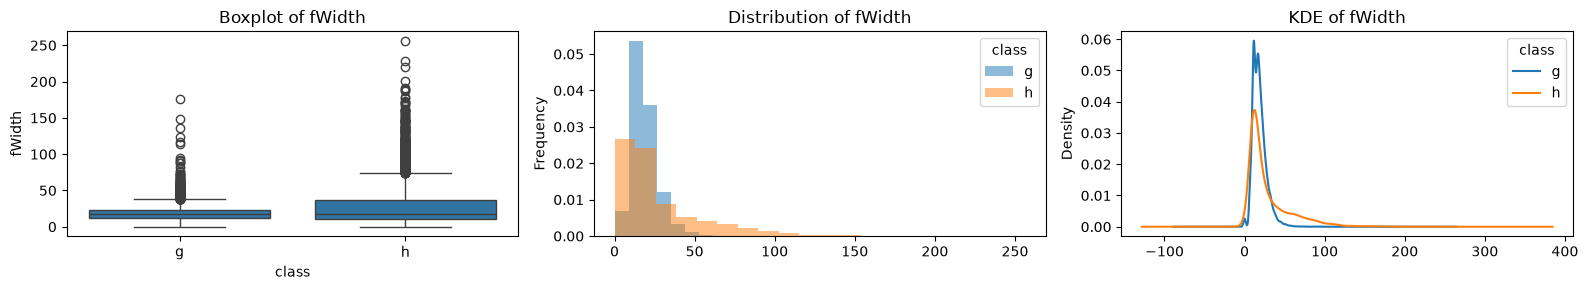

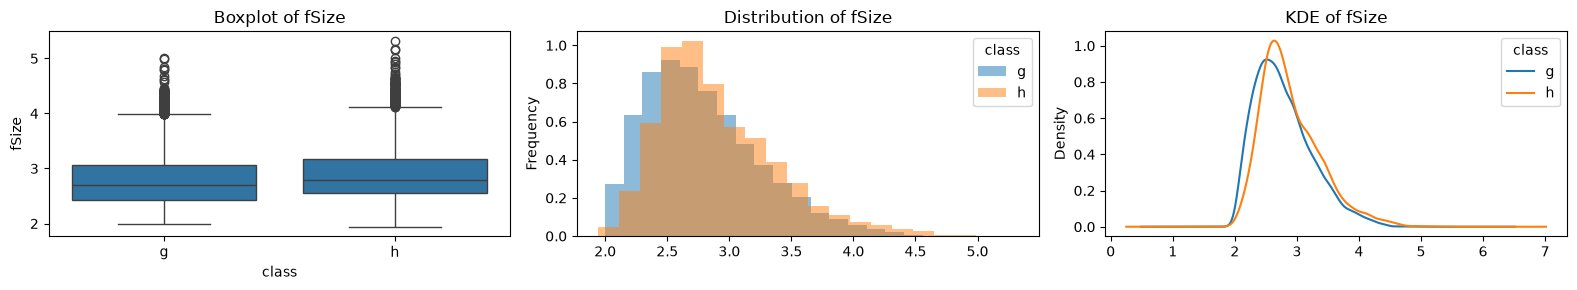

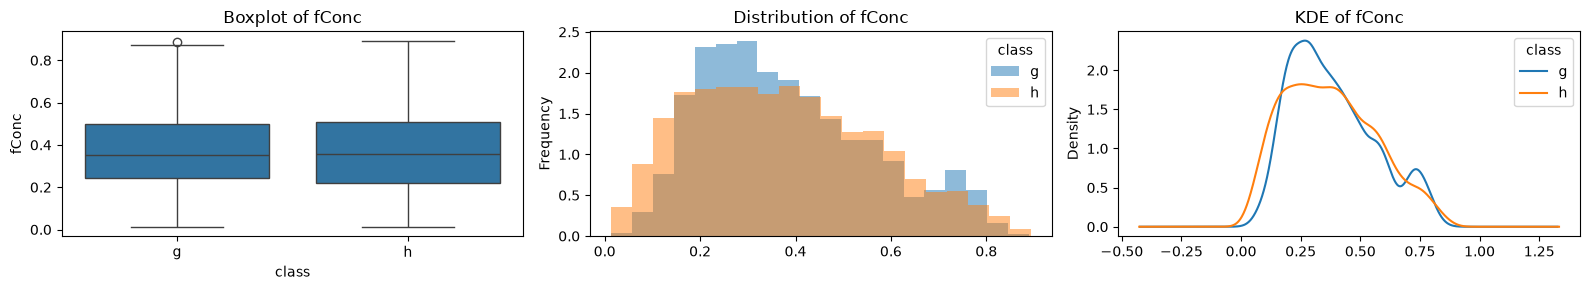

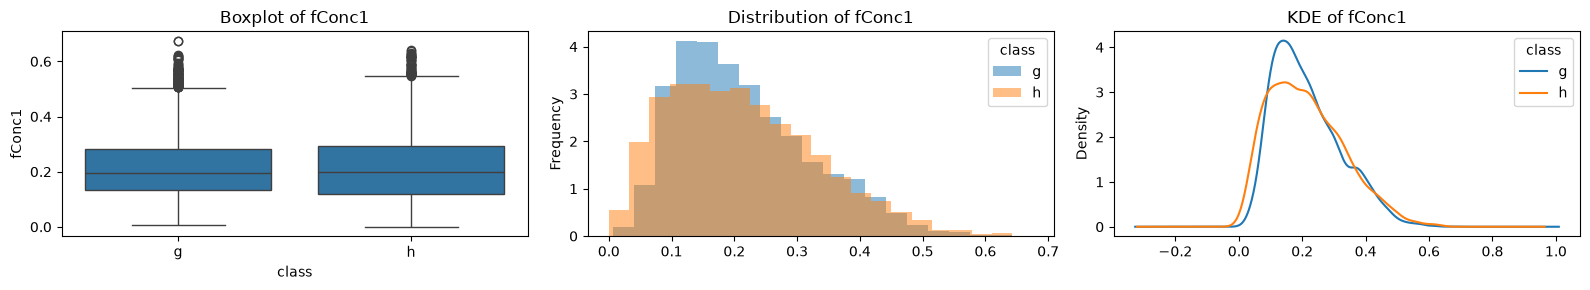

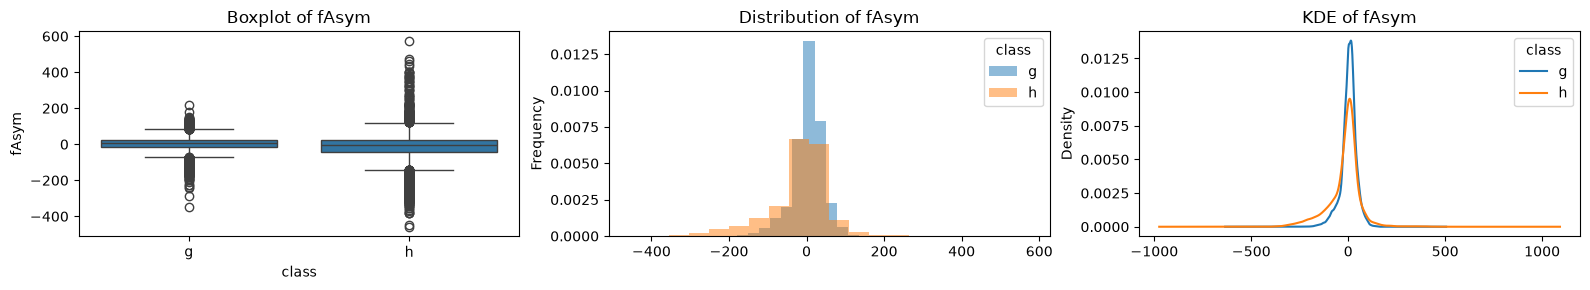

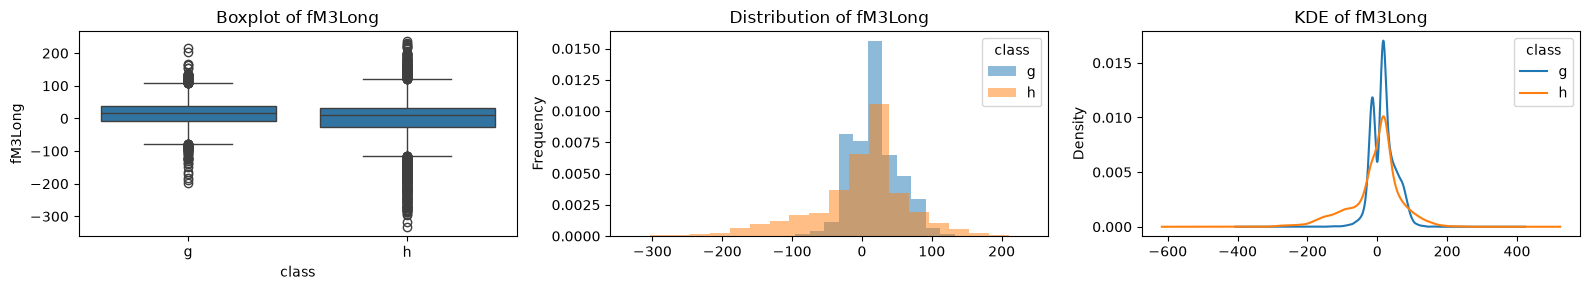

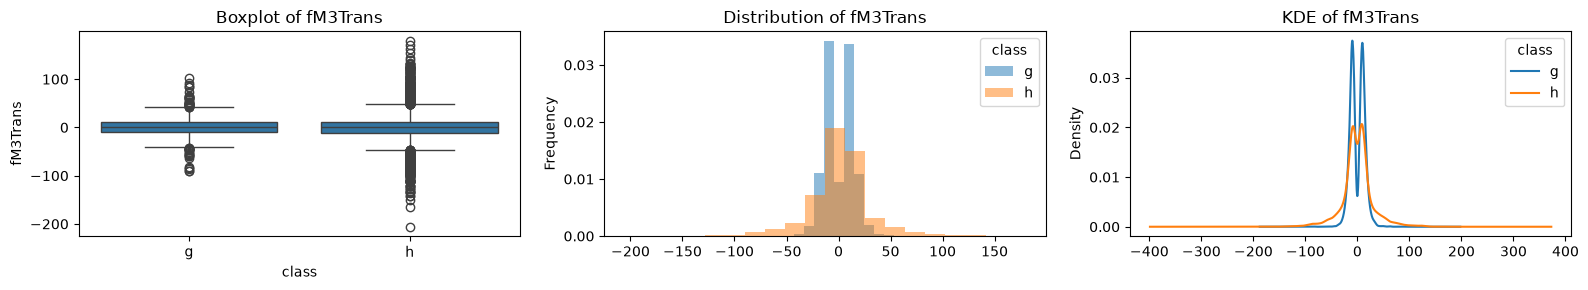

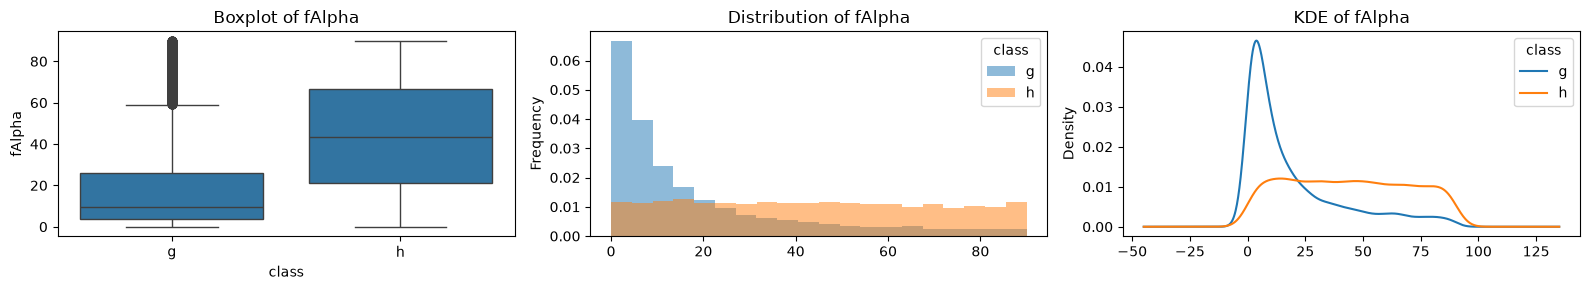

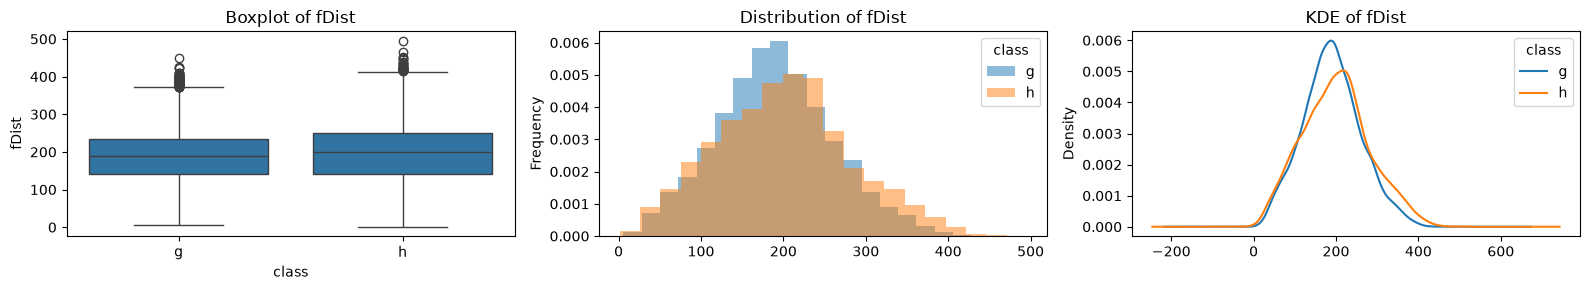

In [24]:
def numplots(col, data=df, key='class', save_plot=False):

    fig, ax = plt.subplots(ncols=3, figsize=(16, 3))

    # Boxplot
    sns.boxplot(data=data, y=col, x=key, ax=ax[0])
    ax[0].set_title(f"Boxplot of {col}")

    # Histogram
    data.groupby(key)[col].plot(
        kind='hist',
        bins=20,
        ax=ax[1],
        alpha=0.5,
        density=True
    )
    ax[1].set_title(f"Distribution of {col}")
    ax[1].legend(title=key)

    # KDE
    data.groupby(key)[col].plot(
        kind='kde',
        ax=ax[2]
    )
    ax[2].set_title(f"KDE of {col}")
    ax[2].legend(title=key)

    plt.tight_layout()

    if save_plot:
        fig.savefig(f"numplot_{col}.png")

    plt.show()
    
for col in features.columns:
    numplots(col)

* fLength besitzt für Gamma events eher kleinere, weniger stark gestreute Werte als für Hadronevents --> interessant, aber nicht allein ausreichend
* fWidth ähnliches Verhalten wie fLength, allerdings etwas weniger stark ausgesprägt --> enthält interessante Information, reicht aufgrund des Überlapps aber nicht um Klassen sauber zu trennen
* fSize sehr schwache Separation zwischen g und h --> weniger interessant
* fConc ebenfalls schwache Separation, h Events lediglich etwas breite Verteilung --> weniger interessant
* fConc1 schwache Separation, h Events etwas breitere Verteilung --> weniger interessant
* fAsym h Events zeigen deutlich breitere Verteilung --> könnte interessant sein
* fM3Long unterschiedliche Verteilung erkennbar, h Events deutlich breitere Verteilung, g Events relativ schmale Verteilung im Bereich kleiner positiver Werte --> könnte interessant sein
* fM3Trans sichtbar unterschiedliche Verteilung, Gamma-Events zwei Peaks nahe zu und symmetrisch um 0 --> könnte interessant sein, evtl. Betrag verwenden
* fAlpha starker Versatz im Boxplot und deutlich verschiedene Verteilungen -->  sehr interessanter Kandidat für Modell
* fDist nur geringfügig unterschiedliche Verteilung, alleine nicht ausreichend um Klassen zu separieren

* für einige Features beobachtungen außerhalb der 1.5 IQR Boxplot-Grenzen, für fAsym, fM3Long, fm3Trans deutlich stärkere ausgeprägt für Hadron, als für Gamma

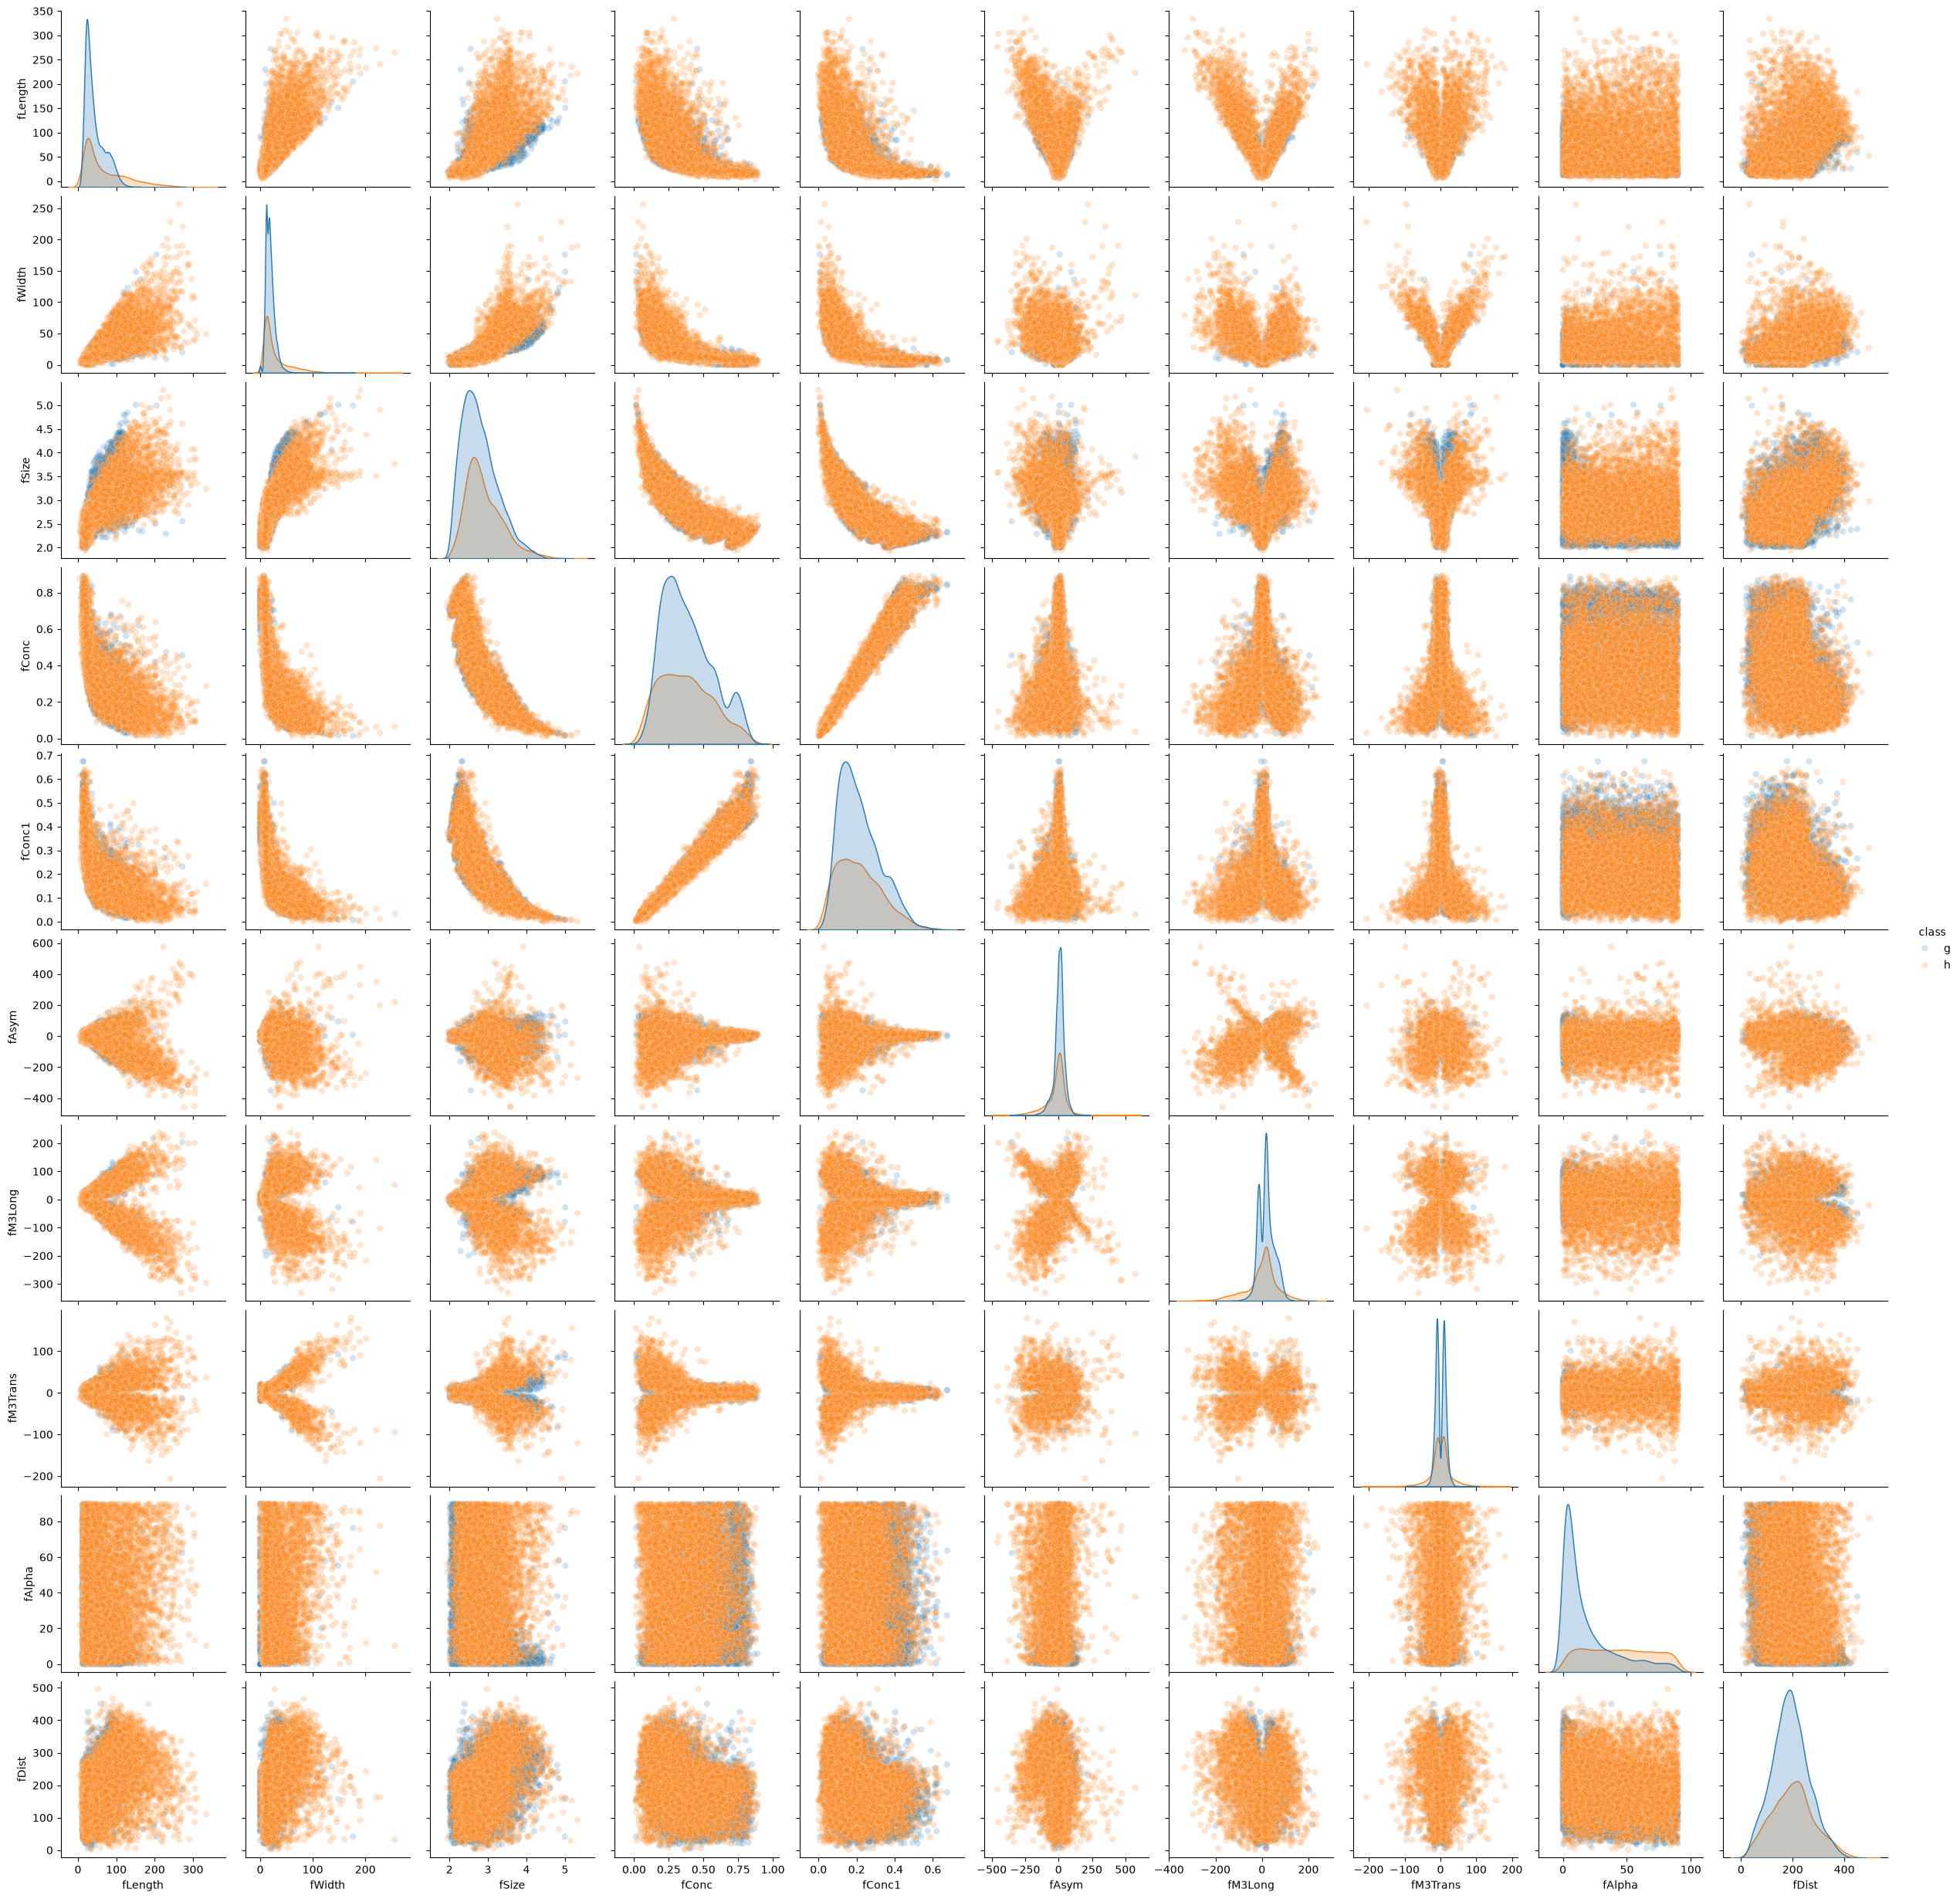

In [25]:
# Scattermatrix gruppiert nach Zielvariable
sns.pairplot(data=df, hue='class', plot_kws={'alpha': 0.2})


* Korrelation zwischen fConc und FConc1 wird auch hier sichtbar
* ebenfalls positive Beziehung zwischen fSize, fLength und fWidth
* negative, nichtlineare Beziehung zwischen fSize, FLength, fWidth mit fConc und fConc1
* fM3Trans bildet mit allen Features eine achsensymmetrische Verteilung --> Betrag als neues Feature
* auch fAsym und fM3Long zeigen achsensymmetrisches Verhalten --> Betrag als neues Feature
* potentielle Ausreißer gehören hauptsächlich zur Klasse h, wirken nicht wie einzelne Punkte weitab, was einem Messfehler entsprechen könnte, sondern eher wie eine natürliche Streuung um bestimmte kontinuierliche Strukturen herum, die nach außen hin abnimmt. In univariater Betrachtung auffällige extreme Datenpunkte wirken in multivariater Betrachtung unauffällig --> potentielle Ausreißer nicht unplausibel, werden beibehalten


In [26]:
# neue Features, die sich aus bisherigen Erkenntnissen ergeben:

# Betrag der symmetrischen Features
df["abs_fAsym"] = df["fAsym"].abs()
df["abs_fM3Long"] = df["fM3Long"].abs()
df["abs_fM3Trans"] = df["fM3Trans"].abs()

# Längen-/Breitenverhältnis
df["width_length_ratio"] = df["fWidth"] / df["fLength"]

# Größe der Hillas-Ellipse
df["ellipse_area"] = df["fLength"] * df["fWidth"] * np.pi

# wie stark dominiert das hellste Pixel die beiden hellsten Pixel
df["brightest_pixel_share"] = df["fConc1"] / df["fConc"]

# Umwandlung von alpha vom Wertebereich 0 bis 90 auf 0 bis 1, 1 entspricht perfekte Ausrichtung zum Kamerazentrum
df["alpha_alignment"] = np.cos(np.deg2rad(df["fAlpha"]))

